# Deep Learning Project – Fashion MNIST

## Fokusområde: Input och Preprocessing

Syftet med detta projekt är att undersöka hur preprocessing påverkar en deep learning-modell för bildklassificering.

Vi använder Fashion MNIST-datasetet som innehåller bilder av olika klädesplagg.

Projektet fokuserar på:

- att förstå datan
- att förbereda input-data
- att analysera hur preprocessing påverkar modellens prestanda

In [158]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist


# Ladda in datasetet

Fashion MNIST finns direkt inbyggt i Keras och kan laddas automatiskt.

Datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder
- 10 olika klasser
- gråskalebilder med storlek 28x28 pixlar

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Undersöka datasetets struktur

Vi börjar med att undersöka:

- hur många bilder som finns
- bildstorlek
- hur labels ser ut

In [3]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# Klassnamn

Fashion MNIST innehåller 10 olika kategorier av kläder och accessoarer.

In [4]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Visualisering av bilder

För att förstå datan bättre visualiserar vi några exempelbilder från datasetet.

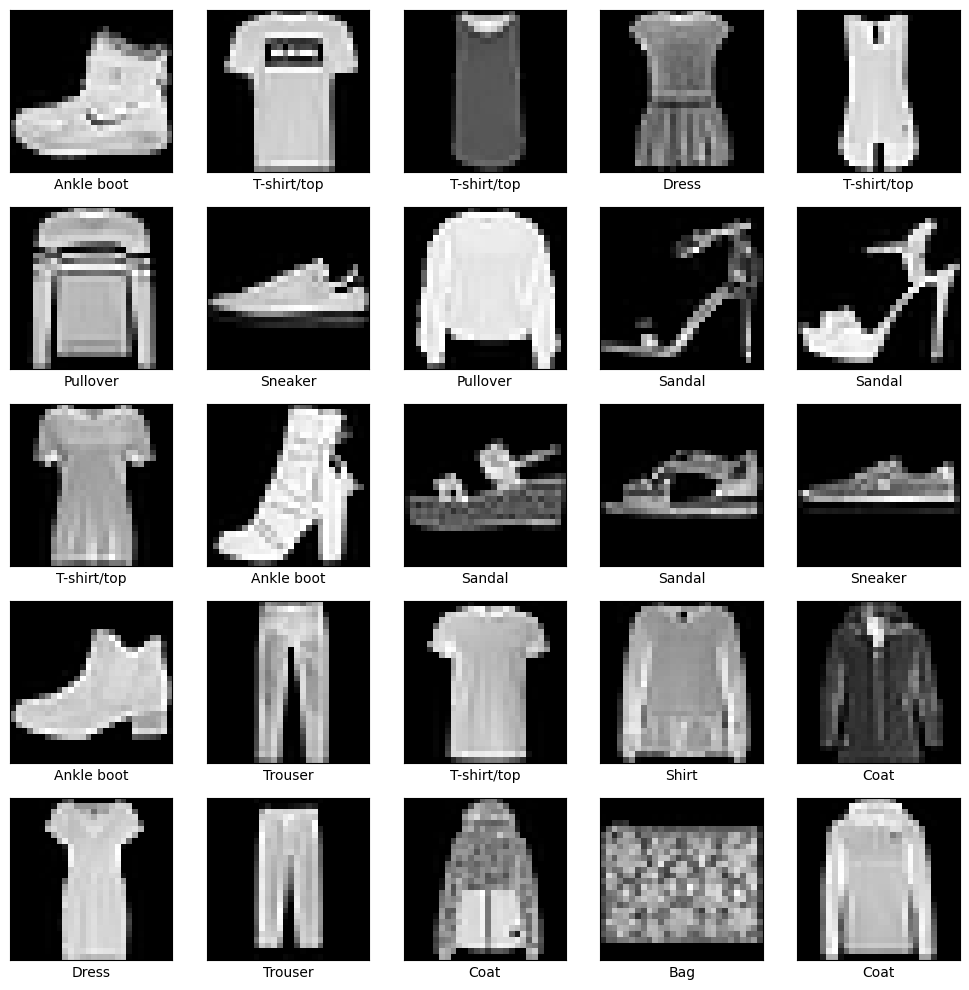

In [5]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

# Analys av klassfördelning

Det är viktigt att kontrollera om datasetet är balanserat.

Om vissa klasser innehåller betydligt fler bilder än andra kan modellen bli biased.

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


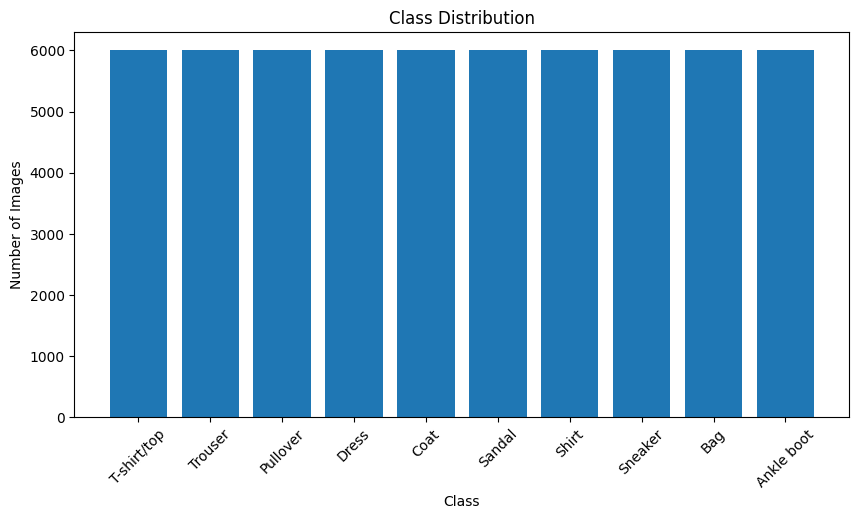

In [7]:
plt.figure(figsize=(10,5))

plt.bar(range(len(unique)), counts)

plt.xticks(range(len(unique)), class_names, rotation=45)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Analys av datasetet

Efter analysen kan vi se att:

- datasetet innehåller 10 klasser
- bilderna är gråskalebilder
- alla bilder har storleken 28x28
- datasetet är relativt balanserat

Detta är positivt eftersom balanserad data minskar risken för bias i modellen.

# Preprocessing av data

Innan datan används i en neural nätverksmodell behöver den preprocessas.

Preprocessing hjälper modellen att:

- träna stabilare
- lära sig snabbare
- förbättra prestanda

# Normalisering

Pixelvärden i bilderna ligger mellan 0 och 255.

Neurala nätverk fungerar bättre när värden skalas mellan 0 och 1.

Därför normaliserar vi bilderna genom att dividera med 255.

# Fokusområde - Input och preprocessing

Det här området handlar om hur datan förbereds innan den används i modellen.  
Ni kan till exempel undersöka:  
normalisering av pixelvärden  
hur datan formas (reshaping)   
skillnaden mellan olika sätt att mata in data i modellen  
Målet är att förstå hur datans format och kvalitet påverkar modellens inlärning.  

Jämförelser:
1. Normaliserad vs onormaliserad data i dense-model
2. Normaliserad vs onormaliserad data i cnn-model
3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)
4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

# Modeller

In [8]:
def create_dense_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
def create_cnn_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 1. Normaliserad vs onormaliserad data i dense-model

In [10]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_train.astype('float32') / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())
print("Min pixel value normalised:", x_train_norm.min())
print("Max pixel value normalised:", x_train_norm.max())

model_dense = create_dense_model()
model_dense_norm = create_dense_model()

history_model_dense = model_dense.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_dense_norm = model_dense_norm.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

Min pixel value: 0
Max pixel value: 255
Min pixel value normalised: 0.0
Max pixel value normalised: 1.0
Epoch 1/10


c:\Users\bosko\Desktop\-fashion-mnist-deep-learning-main\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6205 - loss: 3.3643 - val_accuracy: 0.6565 - val_loss: 0.9395
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6839 - loss: 0.8686 - val_accuracy: 0.6888 - val_loss: 0.7946
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7129 - loss: 0.7365 - val_accuracy: 0.7308 - val_loss: 0.7065
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7389 - loss: 0.6585 - val_accuracy: 0.7345 - val_loss: 0.6988
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7474 - loss: 0.6381 - val_accuracy: 0.7486 - val_loss: 0.6548
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7504 - loss: 0.6211 - val_accuracy: 0.7498 - val_loss: 0.6979
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7528 - loss: 0.6145 - val_accuracy: 0.7495 - val_loss: 0.6306
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7560 - loss: 0.6003 - val_accurac

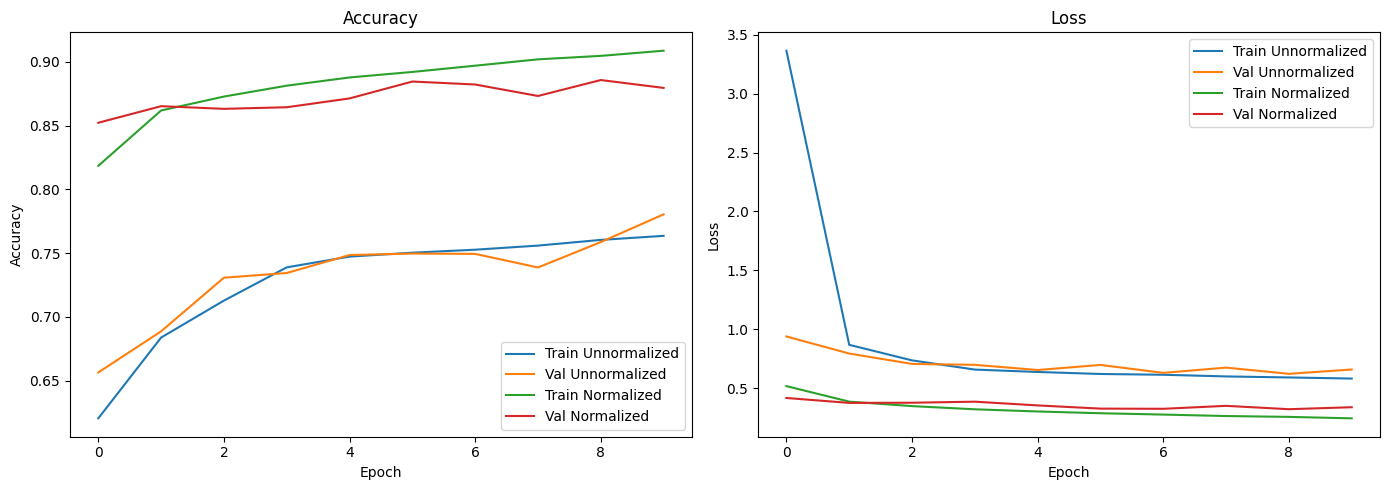

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_dense.history['accuracy'], label='Train Unnormalized')
axes[0].plot(history_model_dense.history['val_accuracy'], label='Val Unnormalized')

axes[0].plot(history_model_dense_norm.history['accuracy'], label='Train Normalized')
axes[0].plot(history_model_dense_norm.history['val_accuracy'], label='Val Normalized')

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_dense.history['loss'], label='Train Unnormalized')
axes[1].plot(history_model_dense.history['val_loss'], label='Val Unnormalized')

axes[1].plot(history_model_dense_norm.history['loss'], label='Train Normalized')
axes[1].plot(history_model_dense_norm.history['val_loss'], label='Val Normalized')

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Normaliserad vs onormaliserad data i cnn-model

In [12]:
model_cnn = create_cnn_model()
model_cnn_norm = create_cnn_model()

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_train_cnn_norm = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.8328 - loss: 0.5968 - val_accuracy: 0.8576 - val_loss: 0.3966
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8864 - loss: 0.3179 - val_accuracy: 0.8898 - val_loss: 0.3032
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9012 - loss: 0.2739 - val_accuracy: 0.8926 - val_loss: 0.3024
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9095 - loss: 0.2471 - val_accuracy: 0.8870 - val_loss: 0.3341
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9147 - loss: 0.2289 - val_accuracy: 0.9013 - val_loss: 0.2656
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9203 - loss: 0.2135 - val_accuracy: 0.8983 - val_loss: 0.2923
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9265 - loss: 0.1947 - val_accuracy: 0.9039 - val_loss: 0.2814
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9328 -

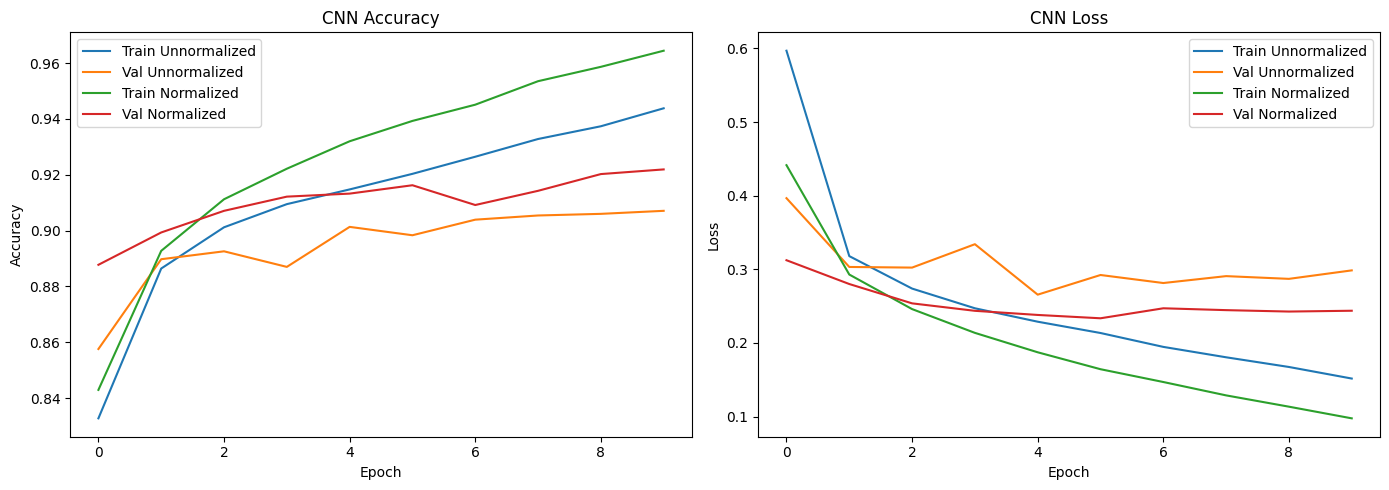

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_cnn.history['accuracy'], label='Train Unnormalized')
axes[0].plot(history_model_cnn.history['val_accuracy'], label='Val Unnormalized')

axes[0].plot(history_model_cnn_norm.history['accuracy'], label='Train Normalized')
axes[0].plot(history_model_cnn_norm.history['val_accuracy'], label='Val Normalized')

axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_cnn.history['loss'], label='Train Unnormalized')
axes[1].plot(history_model_cnn.history['val_loss'], label='Val Unnormalized')

axes[1].plot(history_model_cnn_norm.history['loss'], label='Train Normalized')
axes[1].plot(history_model_cnn_norm.history['val_loss'], label='Val Normalized')

axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)

In [14]:
model_cnn_norm = create_cnn_model()
model_cnn_norm_reshape = create_cnn_model()

x_train_cnn_norm = x_train_norm
x_train_cnn_norm_reshape = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_cnn_norm_reshape = model_cnn_norm_reshape.fit(
    x_train_cnn_norm_reshape,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8436 - loss: 0.4376 - val_accuracy: 0.8780 - val_loss: 0.3362
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8947 - loss: 0.2902 - val_accuracy: 0.8819 - val_loss: 0.3147
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9120 - loss: 0.2443 - val_accuracy: 0.9114 - val_loss: 0.2424
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9233 - loss: 0.2116 - val_accuracy: 0.9073 - val_loss: 0.2548
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9313 - loss: 0.1866 - val_accuracy: 0.9214 - val_loss: 0.2223
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9394 - loss: 0.1648 - val_accuracy: 0.9179 - val_loss: 0.2285
Epoch 7/10
   7/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9419 - loss: 0.1378  

KeyboardInterrupt: 

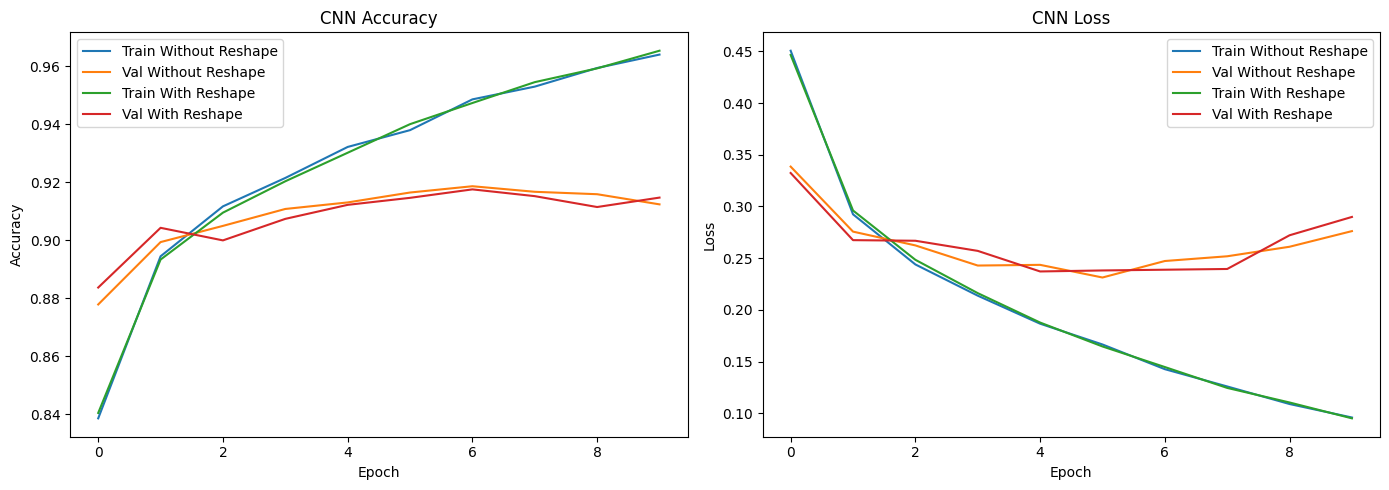

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_cnn_norm.history['accuracy'], label='Train Without Reshape')
axes[0].plot(history_model_cnn_norm.history['val_accuracy'], label='Val Without Reshape')

axes[0].plot(history_model_cnn_norm_reshape.history['accuracy'], label='Train With Reshape')
axes[0].plot(history_model_cnn_norm_reshape.history['val_accuracy'], label='Val With Reshape')

axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_cnn_norm.history['loss'], label='Train Without Reshape')
axes[1].plot(history_model_cnn_norm.history['val_loss'], label='Val Without Reshape')

axes[1].plot(history_model_cnn_norm_reshape.history['loss'], label='Train With Reshape')
axes[1].plot(history_model_cnn_norm_reshape.history['val_loss'], label='Val With Reshape')

axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

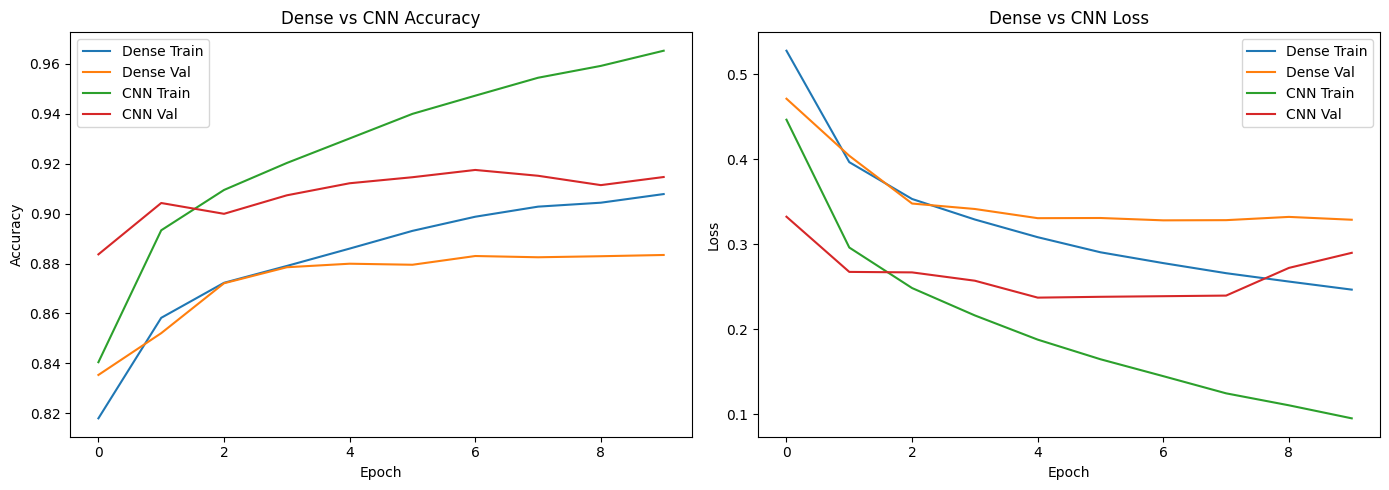

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_dense_norm.history['accuracy'], label='Dense Train')
axes[0].plot(history_model_dense_norm.history['val_accuracy'], label='Dense Val')

axes[0].plot(history_model_cnn_norm_reshape.history['accuracy'], label='CNN Train')
axes[0].plot(history_model_cnn_norm_reshape.history['val_accuracy'], label='CNN Val')

axes[0].set_title('Dense vs CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_dense_norm.history['loss'], label='Dense Train')
axes[1].plot(history_model_dense_norm.history['val_loss'], label='Dense Val')

axes[1].plot(history_model_cnn_norm_reshape.history['loss'], label='CNN Train')
axes[1].plot(history_model_cnn_norm_reshape.history['val_loss'], label='CNN Val')

axes[1].set_title('Dense vs CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Slutsats

I denna del av projektet har vi:

- undersökt datasetet
- analyserat klassfördelning
- normaliserat bilderna
- förberett datan för CNN-modellen

Preprocessing är viktigt eftersom kvaliteten på input-data påverkar modellens resultat.

## Träna modellen

I denna del tränas CNN-modellen på träningsdatan. Vi använder `x_train` och `y_train` som träningsdata.

Vi använder också `validation_split=0.2`, vilket betyder att 20 procent av träningsdatan används som valideringsdata. Det gör att vi kan följa hur modellen presterar på data som den inte tränas direkt på.

Modellen tränas i 10 epoker. En epok betyder att modellen går igenom hela träningsdatan en gång. Genom att följa `accuracy`, `loss`, `val_accuracy` och `val_loss` kan vi se om modellen förbättras över tid.

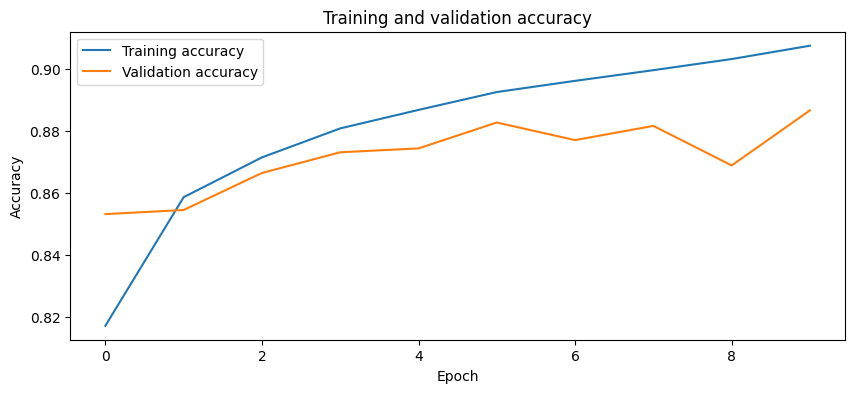

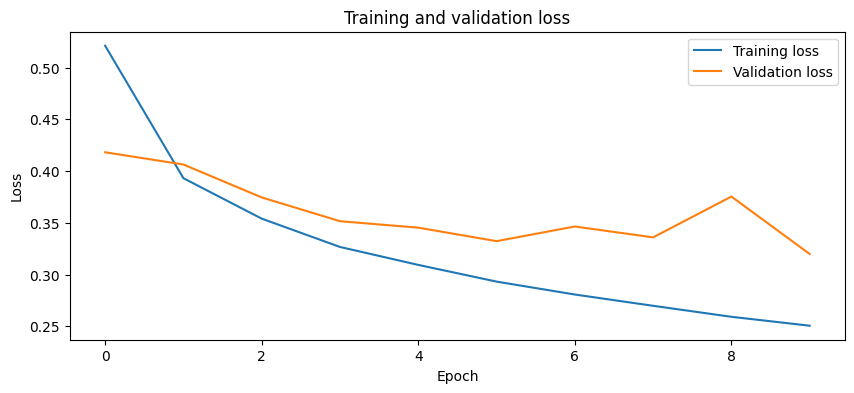

In [ ]:
# Visualisera accuracy och loss

plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Analys av träningen

Under träningen följer vi hur modellens accuracy och loss förändras över tid.

I vårt resultat ökade training accuracy till ungefär 95 %, medan validation accuracy stabiliserades runt 92 %. Detta visar att modellen lär sig träningsdatan bra samtidigt som den fortfarande presterar stabilt på ny data. Skillnaden mellan training och validation accuracy tyder på viss overfitting mot slutet av träningen, men modellen generaliserar fortfarande relativt bra.

## Fördjupning i fokusområde (Input i preprocesing)

In [16]:
x_test_norm = x_test.astype('float32') / 255.0

# Reshape images for CNN

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

print("CNN train shape:", x_train_cnn.shape)
print("CNN test shape:", x_test_cnn.shape)


CNN train shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


In [17]:
# Train CNN model with normalized and reshaped images

model_cnn_preprocessed = create_cnn_model()

history_cnn_preprocessed = model_cnn_preprocessed.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8405 - loss: 0.4435 - val_accuracy: 0.8702 - val_loss: 0.3566
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8921 - loss: 0.2964 - val_accuracy: 0.8970 - val_loss: 0.2803
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9090 - loss: 0.2474 - val_accuracy: 0.9079 - val_loss: 0.2526
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9217 - loss: 0.2150 - val_accuracy: 0.9020 - val_loss: 0.2826
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9307 - loss: 0.1889 - val_accuracy: 0.9102 - val_loss: 0.2456
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9373 - loss: 0.1686 - val_accuracy: 0.9159 - val_loss: 0.2474
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9444 - loss: 0.1487 - val_accuracy: 0.9172 - val_loss: 0.2456
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9525 -

In [18]:
# Evaluate models on test data

dense_loss, dense_acc = model_dense_norm.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

cnn_loss, cnn_acc = model_cnn_preprocessed.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("Dense Test Accuracy:", dense_acc)
print("CNN Test Accuracy:", cnn_acc)

Dense Test Accuracy: 0.8711000084877014
CNN Test Accuracy: 0.9143000245094299


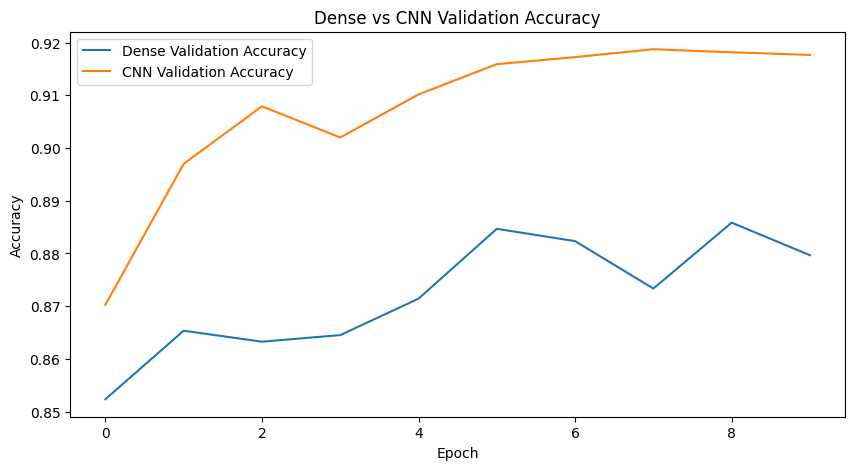

In [19]:
# Compare validation accuracy

plt.figure(figsize=(10,5))

plt.plot(
    history_model_dense_norm.history['val_accuracy'],
    label='Dense Validation Accuracy'
)

plt.plot(
    history_cnn_preprocessed.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.title('Dense vs CNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

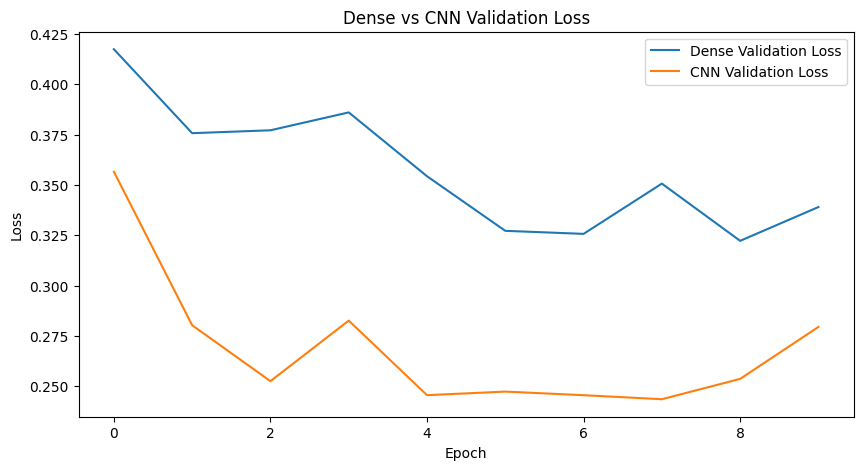

In [20]:
# Compare validation loss

plt.figure(figsize=(10,5))

plt.plot(
    history_model_dense_norm.history['val_loss'],
    label='Dense Validation Loss'
)

plt.plot(
    history_cnn_preprocessed.history['val_loss'],
    label='CNN Validation Loss'
)

plt.title('Dense vs CNN Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Vi jämförde Dense-modellen och CNN-modellen för att undersöka hur preprocessing påverkar modellernas prestanda.

Först användes normalisering där pixelvärdena skalades från intervallet 0–255 till 0–1. Detta gjorde träningen stabilare och hjälpte modellen att lära sig snabbare.

Vi reshapes också bilderna till formatet (28, 28, 1) för CNN-modellen. Detta var viktigt eftersom CNN behöver bildens spatiala struktur för att kunna identifiera mönster som former, kanter och detaljer.

Resultaten visade att CNN-modellen gav högre validation accuracy och lägre loss jämfört med Dense-modellen.

Dense-modellen fungerade bra som en grundmodell, men CNN-modellen kunde analysera bilddata mer effektivt eftersom convolutionslager är anpassade för bildklassificering.

Vi såg även att preprocessing hade stor betydelse för modellens resultat. Utan korrekt preprocessing blev träningen mindre stabil och modellen presterade sämre.

I detta projekt lärde vi oss hur preprocessing och modellarkitektur påverkar deep learning-modeller för bildklassificering.

Vi såg att normalisering förbättrade både accuracy och träningsstabilitet genom att göra inputvärdena mindre och mer jämna.

Vi lärde oss också att CNN-modeller fungerar bättre än Dense-modeller för bilddata eftersom CNN kan bevara och analysera spatial information i bilderna.

Projektet hjälpte oss att förstå hur viktiga preprocessing-tekniker är inom deep learning och hur olika val påverkar modellens prestanda.

Om projektet skulle vidareutvecklas skulle vi vilja testa fler preprocessing-metoder och mer avancerade CNN-arkitekturer för att ytterligare förbättra resultaten.

## Analys och slutsatser för hella projektet

## Hur bra fungerar modellen?

Både Dense-modellen och CNN-modellen fungerade bra för bildklassificering med Fashion MNIST-datasetet.

Dense-modellen kunde klassificera bilder relativt bra och fungerade som en stabil grundmodell. CNN-modellen gav däremot bättre resultat och högre validation accuracy eftersom den är bättre anpassad för bilddata.

CNN-modellen kunde identifiera mönster som former, kanter och detaljer i bilderna, vilket förbättrade modellens prestanda.


## Ser vi tecken på overfitting eller underfitting?

Vi såg vissa tecken på overfitting i CNN-modellen mot slutet av träningen.

Training accuracy fortsatte att förbättras medan validation accuracy ökade långsammare. Detta kan tyda på att modellen började anpassa sig för mycket till träningsdatan.

Vi såg däremot inga tydliga tecken på underfitting eftersom båda modellerna kunde lära sig relevanta mönster från datasetet.

Skillnaden mellan training loss och validation loss var dock relativt liten, vilket visar att modellerna fortfarande generaliserade ganska bra.



## Vilka val hade störst påverkan?

De val som hade störst påverkan på resultatet var:

- normalisering av pixelvärden
- korrekt reshape av bilddata
- korrekt inputformat för CNN-modellen

Normalisering gjorde träningen stabilare och hjälpte modellen att lära sig snabbare.

Reshape var viktigt eftersom CNN-modellen behöver tredimensionell bilddata för att kunna analysera spatial information korrekt.

Vi såg också att korrekt preprocessing förbättrade både accuracy och modellens stabilitet under träningen.


## Vilka begränsningar finns?

Projektet har flera begränsningar.

Datasetet Fashion MNIST består av relativt små och enkla gråskalebilder, vilket gör problemet enklare än verkliga bildklassificeringsproblem.

Vi testade också endast ett begränsat antal modeller och hyperparametrar.

Dessutom använde vi inte mer avancerade tekniker som:

- data augmentation
- dropout
- regularisering
- djupare CNN-arkitekturer

Med fler experiment och mer avancerade modeller hade resultaten sannolikt kunnat förbättras ytterligare.